# 1. Model (improved)

Classification Report:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8858695652173914
Precision: 0.8872051588884458
Recall: 0.8858695652173914
F1-Score: 0.8852184150325296


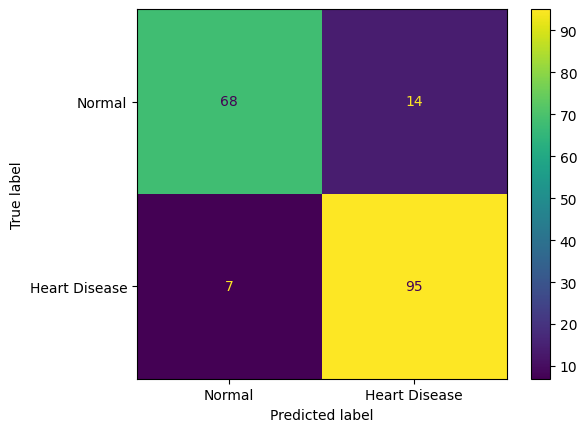

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

train = pd.read_csv("../1-Data/train_processed.csv")
x_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]

C = 0.01 # Regularization strength
threshold = 0.45 # Adjust the threshold for classifying as heart disease

model = LogisticRegression(C=C, random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = (model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()

# 2. Error analysis

In [2]:
import pandas as pd
from IPython.display import display

# wrong prediction probability for further analysis
y_proba=model.predict_proba(x_test)[:, 1]

# Reread test data (preprocessed)
test_original=pd.read_csv("../1-Data/test_data.csv")

# group as table
df=test_original.copy()
df["True_Label"]=y_test.values
df["Predicted_Label"]=y_pred
df["Predicted_Prob"]=y_proba

# Filter incorrectly predicted cases
wrong=df[df["True_Label"]!=df["Predicted_Label"]]
print("\nTotal incorrect case:", len(wrong))

# Two false category
# 1. False Positive: Healthy patient labeled as ill
fp=wrong[(wrong["True_Label"]==0)&(wrong["Predicted_Label"]==1)]

# 2. False Negative (Dangerous): Ill patient labeled as healthy
fn=wrong[(wrong["True_Label"]==1)&(wrong["Predicted_Label"]==0)]

# Full display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
print(f"\n--- False Positives: {len(fp)} case ---")
display(fp)
print(f"\n--- False Negatives: {len(fn)} case ---")
display(fn)

# reset max
pd.reset_option("display.max_columns")
pd.reset_option("display.max_rows")


Total incorrect case: 21

--- False Positives: 14 case ---


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,True_Label,Predicted_Label,Predicted_Prob
47,41,1,135,203,0,132,0,0.0,1,0,0,1,0,1,0,0,0,1,0.485325
49,44,1,120,184,0,142,0,1.0,1,0,0,1,0,1,0,0,0,1,0.516994
50,53,1,80,0,0,141,1,2.0,0,0,0,1,0,0,0,0,0,1,0.745496
55,41,1,130,214,0,168,0,2.0,0,1,0,0,0,1,0,0,0,1,0.579642
72,51,0,114,258,1,96,0,1.0,0,0,0,0,0,0,1,0,0,1,0.456099
94,63,1,126,0,0,120,0,1.5,0,0,0,0,1,0,0,0,0,1,0.694913
118,41,1,150,171,0,128,1,1.5,0,0,0,1,0,1,0,0,0,1,0.845613
132,45,0,138,236,0,152,1,0.2,0,0,0,0,0,1,0,0,0,1,0.676455
137,51,1,132,218,1,139,0,0.1,0,0,0,0,0,0,1,0,0,1,0.490421
139,52,1,118,186,0,190,0,0.0,0,0,1,0,0,1,0,0,0,1,0.472924



--- False Negatives: 7 case ---


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease,True_Label,Predicted_Label,Predicted_Prob
10,34,1,115,0,1,154,0,0.2,0,0,0,1,0,0,1,1,1,0,0.399143
41,49,0,160,180,0,156,0,1.0,0,1,0,1,0,1,0,1,1,0,0.370699
80,59,1,160,273,0,125,0,0.0,0,0,1,0,0,0,1,1,1,0,0.273031
107,59,1,134,204,0,162,0,0.8,0,0,1,1,0,0,1,1,1,0,0.213664
113,57,1,124,261,0,141,0,0.3,1,0,0,1,0,0,1,1,1,0,0.188457
115,52,1,128,0,0,180,0,3.0,0,1,0,0,1,0,1,1,1,0,0.277735
159,48,1,110,229,0,168,0,1.0,1,0,0,1,0,0,0,1,1,0,0.310818


Case 1: No 174 - False Positive
- Input (main): Age 57, RestingBP 130, Oldpeak: 1.0, - ExerciseAngina: 1
- True Label: 0 (Healthy)
- Predicted prob: 0.898
The model is overconfident in a wrong prediction. It overestimate factors like ExerciseAngina and Oldpeak, treating them as definitive evidence of heart disease. This bias leads to false positives even when clinical markers are not conclusive. Increase penalty terms to prevent the model from becoming overly sensitive to individual features would be useful.

Case 2: No 80 - False Negative
- Input (main): Age 59, RestingBP 160, MaxHR 125. Oldpeak: 1.0
- True Label: 1
- Predicted prob: 0.273
The model failed to identify this patient as high-risk despite the critical RestingBP of 160. This shows that it relies too much on Oldpeak as the primary indicator, but ignores high age and high blood pressure (which is still risky).

Case 3: No 115 - False Negative
- Input (main): Age 48, MaxHR 168, Oldpeak 1.0, ExerciseAngina 0
- True Label: 1
- Predicted prob: 0.311
The model predicted no disease because the patient has a high MaxHR and no chest pain during exercise. It assumes this means the person is fit, so it underestimates the actual risk.

The model can be improved by adding interaction features like Age × RestingBP to better capture combined risk factors that are currently missed (False Negatives). The dataset should also be cleaned by replacing Cholesterol values of 0 with the median, since these can be misinterpreted as healthy. If False Positives are still an issue, the regularization strength (C) can be adjusted to reduce sensitivity and improve overall prediction stability.
